# VoluBrain

- **Authors:**

  María Martínez Matamoros (m.martinezm@udc.es)  
  Nurgul Autayeva (nurgul.autayeva@udc.es)

- **Course:**

  Biomedical Image Analysis — 2025/2026

## 0. Install dependencies

In [4]:
!pip install monai nibabel -q

## 1. GPU setup and imports

In [5]:
import warnings
warnings.filterwarnings("ignore", message=".*cuda.cudart.*")

import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import torch, monai

from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split

from monai.data import Dataset, DataLoader
from monai.transforms import ( Compose, LoadImaged,
    EnsureChannelFirstd, CropForegroundd, NormalizeIntensityd,
    EnsureTyped, Orientationd, Spacingd, RandCropByPosNegLabeld)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("No GPU found, using CPU")

print(f"Device: {device}")

GPU available: Tesla T4
Device: cuda


## 2. Mount Google Drive

In [6]:
from google.colab import drive

drive.mount("/content/gdrive", force_remount=True)

drive_root = "/content/gdrive/MyDrive/IMCV/BMIA"

print(f"Drive root: {drive_root}")
print("Contents:")
for item in sorted(os.listdir(drive_root)):
    print(f"  {item}")

Mounted at /content/gdrive
Drive root: /content/gdrive/MyDrive/IMCV/BMIA
Contents:
  Project_Hippocampus.ipynb
  Task04_Hippocampus
  exploration.ipynb


## 3. Dataset paths

In [7]:
data_root = os.path.join(drive_root, "Task04_Hippocampus")
images_dir = os.path.join(data_root, "imagesTr")
labels_dir = os.path.join(data_root, "labelsTr")
json_file = os.path.join(data_root, "dataset.json")

# Verify directories exist
for path in [images_dir, labels_dir]:
    exists = os.path.isdir(path)
    status = "OK" if exists else "MISSING"
    print(f"[{status}]  {path}")

# List available files
image_files = sorted(glob.glob(os.path.join(images_dir, "*.nii.gz")))
label_files = sorted(glob.glob(os.path.join(labels_dir, "*.nii.gz")))

print(f"\nImages found : {len(image_files)}")
print(f"Labels found : {len(label_files)}")

[OK]  /content/gdrive/MyDrive/IMCV/BMIA/Task04_Hippocampus/imagesTr
[OK]  /content/gdrive/MyDrive/IMCV/BMIA/Task04_Hippocampus/labelsTr

Images found : 260
Labels found : 260


## 4. Exploration  —  NIfTI volume

In [8]:
# Load one sample with nibabel to inspect its raw structure
sample_img_path = image_files[0]
sample_lbl_path = label_files[0]

img_nib = nib.load(sample_img_path)
lbl_nib = nib.load(sample_lbl_path)

img_data = img_nib.get_fdata()   # numpy array (X, Y, Z)
lbl_data = lbl_nib.get_fdata()

print(f"File       : {os.path.basename(sample_img_path)}")
print(f"Shape      : {img_data.shape}  (X, Y, Z)")
print(f"Dtype      : {img_data.dtype}")
print(f"Voxel size : {img_nib.header.get_zooms()} mm")
print(f"Intensity  : min={img_data.min():.1f}  max={img_data.max():.1f}  mean={img_data.mean():.1f}")
print()
print(f"Label shape  : {lbl_data.shape}")
print(f"Unique labels: {np.unique(lbl_data).astype(int)}  -> 0=bg, 1=Anterior, 2=Posterior")

# Voxel count per class
for cls, name in [(0, "background"), (1, "Anterior"), (2, "Posterior")]:
    n   = (lbl_data == cls).sum()
    pct = 100 * n / lbl_data.size
    print(f"  class {cls} ({name:10s}): {n:8d} voxels  ({pct:.2f}%)")

File       : hippocampus_001.nii.gz
Shape      : (35, 51, 35)  (X, Y, Z)
Dtype      : float64
Voxel size : (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm
Intensity  : min=2.0  max=139.0  mean=63.5

Label shape  : (35, 51, 35)
Unique labels: [0 1 2]  -> 0=bg, 1=Anterior, 2=Posterior
  class 0 (background):    59527 voxels  (95.28%)
  class 1 (Anterior  ):     1324 voxels  (2.12%)
  class 2 (Posterior ):     1624 voxels  (2.60%)


## 5. Visualization  —  three orthogonal planes

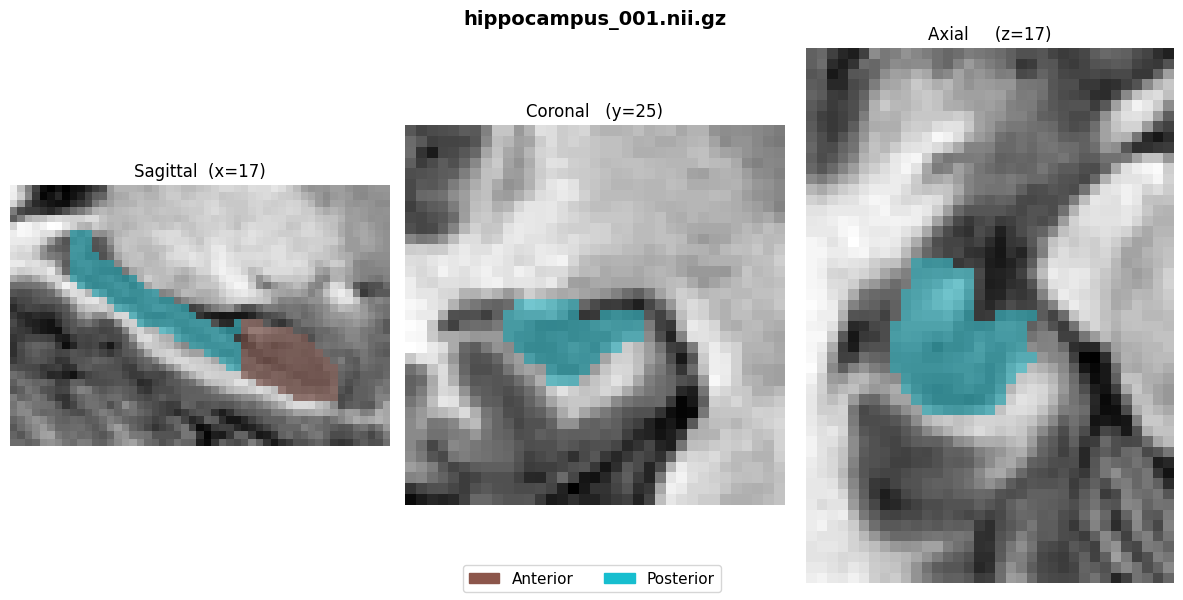

In [9]:
def plot_three_planes(img, lbl, title=""):
    """
    Display sagittal, coronal and axial slices with segmentation overlay.
    """
    cx, cy, cz = [s // 2 for s in img.shape]

    planes = [
        (img[cx, :, :], lbl[cx, :, :], f"Sagittal  (x={cx})"),
        (img[:, cy, :], lbl[:, cy, :], f"Coronal   (y={cy})"),
        (img[:, :, cz], lbl[:, :, cz], f"Axial     (z={cz})")]

    cmap_seg = plt.colormaps["tab10"].resampled(3)

    fig, axes = plt.subplots(1, 3, figsize=(12, 6))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    for ax, (img_slice, lbl_slice, plane_name) in zip(axes, planes):
        ax.imshow(img_slice.T, cmap="gray", origin="lower")
        mask = np.ma.masked_where(lbl_slice == 0, lbl_slice)
        ax.imshow(mask.T, cmap=cmap_seg, alpha=0.5, origin="lower", vmin=0, vmax=2)
        ax.set_title(plane_name)
        ax.axis("off")

    legend = [
        Patch(color=cmap_seg(1), label="Anterior"),
        Patch(color=cmap_seg(2), label="Posterior")]

    fig.legend(handles=legend, loc="lower center", ncol=2, fontsize=11)
    plt.tight_layout()
    plt.show()


plot_three_planes(img_data, lbl_data, title=os.path.basename(sample_img_path))

## 6. Global dataset statistics

In [10]:
print("Analysing all volumes...")

shapes   = []
spacings = []
int_mins = []
int_maxs = []

for img_path in image_files:
    nii  = nib.load(img_path)
    data = nii.get_fdata()
    shapes.append(data.shape)
    spacings.append(nii.header.get_zooms()[:3])
    int_mins.append(data.min())
    int_maxs.append(data.max())

shapes   = np.array(shapes)
spacings = np.array(spacings)

print(f"{'-'*40}")
print(f"  Total volumes       : {len(image_files)}")
print(f"\n  Shapes (X, Y, Z):")
print(f"    Min    : {shapes.min(axis=0)}")
print(f"    Max    : {shapes.max(axis=0)}")
print(f"    Mean   : {shapes.mean(axis=0).astype(int)}")
all_same = len(set(map(tuple, shapes))) == 1
print(f"    Uniform: {'Yes' if all_same else 'No (variable sizes)'}")
print(f"\n  Voxel spacing (mm):")
print(f"    Mean   : {spacings.mean(axis=0).round(3)}")
print(f"    Min    : {spacings.min(axis=0).round(3)}")
print(f"    Max    : {spacings.max(axis=0).round(3)}")
print(f"\n  Intensities:")
print(f"    Global min : {np.min(int_mins):.1f}")
print(f"    Global max : {np.max(int_maxs):.1f}")

Analysing all volumes...
----------------------------------------
  Total volumes       : 260

  Shapes (X, Y, Z):
    Min    : [31 40 24]
    Max    : [43 59 47]
    Mean   : [35 49 35]
    Uniform: No (variable sizes)

  Voxel spacing (mm):
    Mean   : [1. 1. 1.]
    Min    : [1. 1. 1.]
    Max    : [1. 1. 1.]

  Intensities:
    Global min : 0.0
    Global max : 1704295.2


## 7. Build image-label pairs

In [11]:
# List of dicts {image, label}
data_dicts = [
    {"image": img, "label": lbl}
    for img, lbl in zip(image_files, label_files)]

# Verify image <-> label alignment for the first few pairs
print("Alignment check (first 5 pairs):")
for d in data_dicts[:5]:
    img_id = os.path.basename(d["image"]).replace(".nii.gz", "")
    lbl_id = os.path.basename(d["label"]).replace(".nii.gz", "")
    status = "OK" if img_id == lbl_id else "MISMATCH"
    print(f"  [{status}]  {img_id}  <->  {lbl_id}")

print(f"\nTotal pairs: {len(data_dicts)}")

Alignment check (first 5 pairs):
  [OK]  hippocampus_001  <->  hippocampus_001
  [OK]  hippocampus_003  <->  hippocampus_003
  [OK]  hippocampus_004  <->  hippocampus_004
  [OK]  hippocampus_006  <->  hippocampus_006
  [OK]  hippocampus_007  <->  hippocampus_007

Total pairs: 260


## 8. Train / Validation / Test split

In [12]:
seed = 1011

train_val, test_files = train_test_split(
    data_dicts,
    test_size=0.15,
    random_state=seed)

train_files, val_files = train_test_split(
    train_val,
    test_size=0.1765,  # ≈ 0.15 / 0.85
    random_state=seed)

print("Data Split Summary")
print("-" * 40)
print(f"Train samples : {len(train_files):3d}")
print(f"Val samples   : {len(val_files):3d}")
print(f"Test samples  : {len(test_files):3d}")
print("-" * 40)
print(f"Total samples : {len(data_dicts):3d}")

Data Split Summary
----------------------------------------
Train samples : 181
Val samples   :  40
Test samples  :  39
----------------------------------------
Total samples : 260


## **9. Transforms (preprocessing) - Review with state of the art**

Improvement: data augmentation, CropForegroundd, transfer learning (?)

In [13]:
# Patch size (based on minimum volume size)
patch_size = (24, 32, 24)

# Number of patches sampled per volume
num_samples = 4

# Common preprocessing (train + val + test)
base_transforms = [
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS", labels=None),
    NormalizeIntensityd(keys="image", nonzero=True)]

# Train-only preprocessing
train_transforms = Compose(
    base_transforms + [
        RandCropByPosNegLabeld(
            keys=["image", "label"],
            label_key="label",
            spatial_size=patch_size,
            pos=1,
            neg=1,
            num_samples=num_samples,
            image_key="image",
            image_threshold=0),
        EnsureTyped(keys=["image", "label"])])

# Validation / Test preprocessing
test_val_transforms = Compose(
    base_transforms + [EnsureTyped(keys=["image", "label"])])

## 10. Datasets and DataLoaders

In [14]:
train_ds = Dataset(data=train_files, transform=train_transforms)
val_ds = Dataset(data=val_files, transform=test_val_transforms)
test_ds = Dataset(data=test_files, transform=test_val_transforms)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

print("DataLoaders created")
print(f"  Train dataset : {len(train_ds)} volumes  -> {len(train_loader)} batches")
print(f"  Val dataset   : {len(val_ds)} volumes   -> {len(val_loader)} batches")
print(f"  Test dataset  : {len(test_ds)} volumes   -> {len(test_loader)} batches")

DataLoaders created
  Train dataset : 181 volumes  -> 46 batches
  Val dataset   : 40 volumes   -> 40 batches
  Test dataset  : 39 volumes   -> 39 batches


## 11. Verification: review one batch

In [15]:
# Pull one batch and verify shapes and value ranges
batch  = next(iter(train_loader))
imgs   = batch["image"]   # (B * NUM_SAMPLES, 1, X, Y, Z)
labels = batch["label"]

# Move to GPU (just to confirm the transfer works)
imgs_gpu   = imgs.to(device)
labels_gpu = labels.to(device)

print(f"Batch image shape  : {imgs.shape}")
print(f"Batch label shape  : {labels.shape}")
print(f"Image dtype        : {imgs.dtype}")
print(f"Label dtype        : {labels.dtype}")
print(f"Image value range  : [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"Label classes      : {labels.unique().tolist()}")
print(f"Tensors on device  : {imgs_gpu.device}")

Batch image shape  : torch.Size([16, 1, 24, 32, 24])
Batch label shape  : torch.Size([16, 1, 24, 32, 24])
Image dtype        : torch.float32
Label dtype        : torch.float32
Image value range  : [-2.474, 8.858]
Label classes      : [0.0, 1.0, 2.0]
Tensors on device  : cuda:0


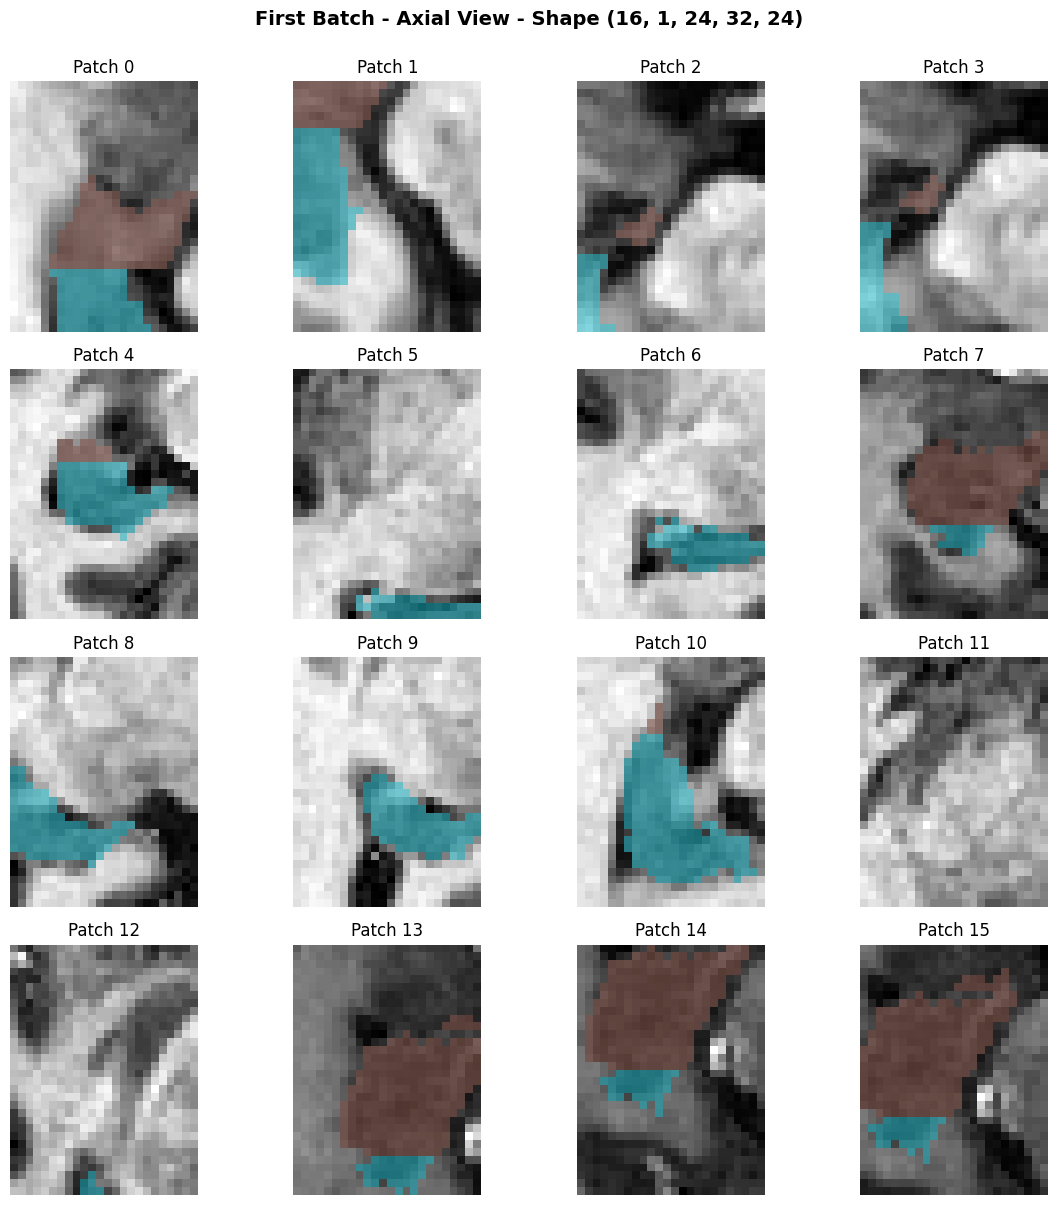

In [16]:
def plot_batch_patches(img_tensor, lbl_tensor, n_cols=4):
    """
    Visualization of the 16 3D patches from the first batch in axial view with overlays.
    """
    n_patches = img_tensor.shape[0]
    n_rows = (n_patches + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
    axes = axes.flatten()

    fig.suptitle(
        f"First Batch - Axial View - Shape {tuple(img_tensor.shape)}",
        fontsize=14, fontweight="bold", y=1.0)

    for i in range(n_patches):
        img = img_tensor[i, 0].cpu().numpy()
        lbl = lbl_tensor[i, 0].cpu().numpy()

        z_mid = img.shape[2] // 2

        axes[i].imshow(img[:, :, z_mid].T, cmap="gray", origin="lower")

        mask = np.ma.masked_where(lbl[:, :, z_mid] == 0, lbl[:, :, z_mid])
        axes[i].imshow(mask.T, cmap="tab10", alpha=0.5, origin="lower", vmin=0, vmax=2)

        axes[i].set_title(f"Patch {i}")
        axes[i].axis("off")

    for j in range(n_patches, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

plot_batch_patches(imgs, labels)